# Periodic Table of Visualization Methods: JupyterLite / Pyodide Notebook

This revised notebook provides one runnable, browser-friendly Python example for each of the 100 visualization methods in Ralph Lengler and Martin J. Eppler's *Periodic Table of Visualization Methods*.

Each element is intentionally short, but the code is no longer hidden behind a single dispatch function. Every example cell shows the construction steps: create or select data, create the figure/axes, draw marks or shapes, add labels/annotation, and display the result. The notebook uses only Pyodide/JupyterLite-friendly packages: `numpy`, `pandas`, `matplotlib`, and `networkx`.

The data are generated inside the notebook so it can run offline in JupyterLite after the listed packages are available.


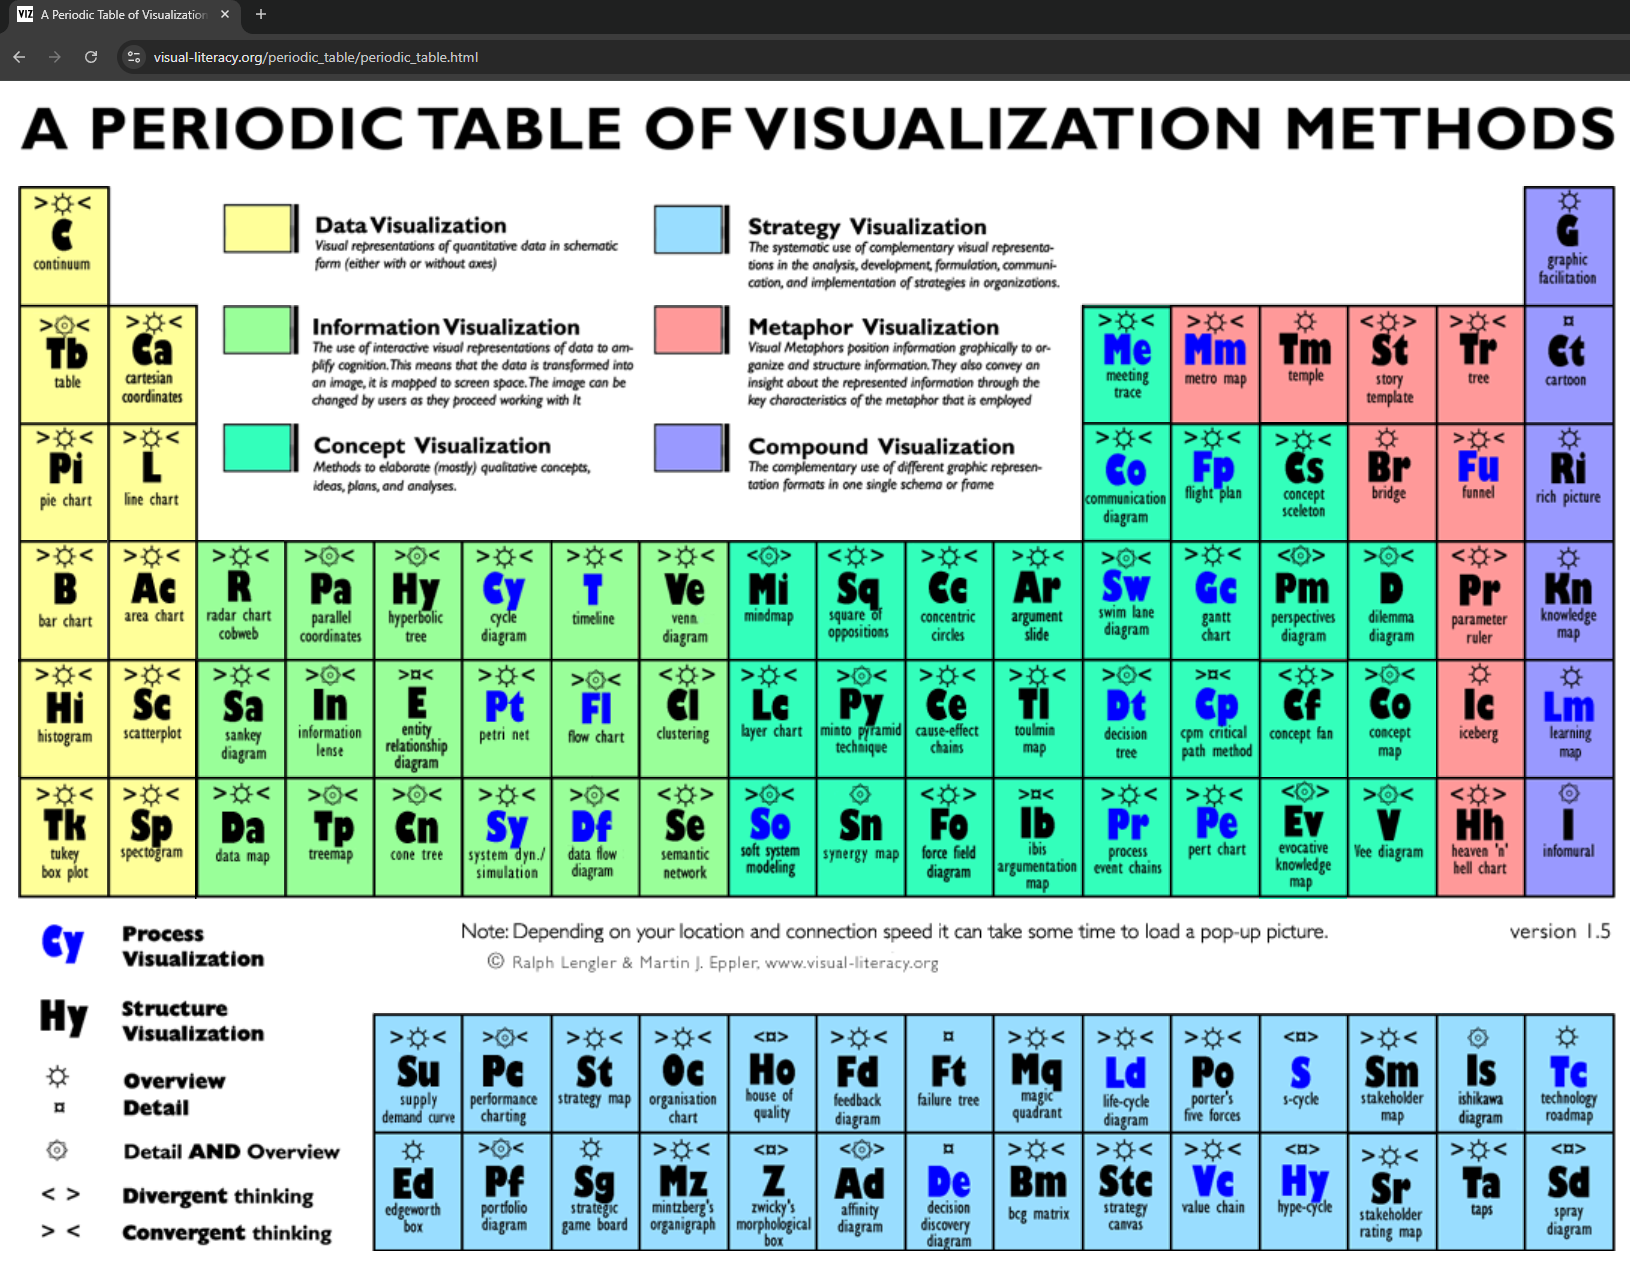

In [ ]:
# Setup: JupyterLite-friendly imports, generated teaching datasets, and light helpers

# In JupyterLite/Pyodide this installs packages in the browser kernel.
# In local Python kernels, piplite is usually unavailable, so the block is skipped.
try:
    import piplite
except Exception:
    piplite = None

if piplite is not None:
    await piplite.install(["numpy", "pandas", "matplotlib", "networkx"])

import math
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
from IPython.display import display
from pandas.plotting import parallel_coordinates
from matplotlib.sankey import Sankey

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.max_open_warning"] = 0
rng = np.random.default_rng(42)

# Small generated datasets used throughout the notebook.
months = pd.date_range("2024-01-01", periods=12, freq="MS")
monthly = pd.DataFrame({
    "month": months,
    "visits": [120, 135, 150, 160, 155, 178, 190, 205, 198, 220, 235, 250],
    "reports": [18, 22, 25, 29, 26, 31, 34, 39, 37, 41, 44, 48],
    "baseline": [130, 132, 135, 140, 145, 150, 158, 166, 172, 180, 188, 195]
})

programs = pd.DataFrame({
    "program": ["Alpha", "Beta", "Gamma", "Delta", "Epsilon"],
    "reach": [84, 62, 45, 73, 55],
    "cost": [32, 48, 28, 60, 40],
    "quality": [78, 71, 88, 65, 82],
    "risk": [20, 35, 25, 55, 30]
})

scores = pd.DataFrame({
    "group": np.repeat(["North", "South", "East"], 40),
    "value": np.r_[rng.normal(70, 8, 40), rng.normal(62, 10, 40), rng.normal(76, 7, 40)]
})

features = pd.DataFrame({
    "item": ["A", "B", "C", "D", "E", "F"],
    "x": [1.0, 1.8, 2.4, 3.5, 4.0, 4.8],
    "y": [2.0, 2.8, 1.5, 3.2, 2.4, 3.8],
    "cluster": ["red", "red", "blue", "green", "blue", "green"]
})

def finish(title):
    """Consistent finishing step for long JupyterLite runs."""
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close("all")

def add_box(ax, xy, text, width=1.35, height=0.55, fontsize=9):
    x, y = xy
    box = patches.FancyBboxPatch(
        (x - width/2, y - height/2), width, height,
        boxstyle="round,pad=0.06", fill=False, linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, wrap=True)

def add_arrow(ax, start, end, label=None, curve=0.0):
    style = f"arc3,rad={curve}" if curve else "arc3"
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", lw=1.2, connectionstyle=style))
    if label:
        mx = (start[0] + end[0]) / 2
        my = (start[1] + end[1]) / 2
        ax.text(mx, my, label, ha="center", va="bottom", fontsize=8)

def draw_network(title, nodes, edges, layout="spring", directed=False):
    G = nx.DiGraph() if directed else nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    if layout == "circular":
        pos = nx.circular_layout(G)
    elif layout == "shell":
        pos = nx.shell_layout(G)
    elif layout == "kamada":
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G, seed=7)
    nx.draw_networkx_nodes(G, pos, node_size=1800)
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, arrows=directed, arrowstyle="->", arrowsize=14)
    plt.axis("off")
    finish(title)


## Catalog

| # | Category | Method |
|---:|---|---|
| 1 | Data visualization | Continuum |
| 2 | Data visualization | Cartesian coordinates |
| 3 | Data visualization | Table |
| 4 | Data visualization | Pie chart |
| 5 | Data visualization | Line chart |
| 6 | Data visualization | Bar chart |
| 7 | Data visualization | Histogram |
| 8 | Data visualization | Area chart |
| 9 | Data visualization | Scatterplot |
| 10 | Data visualization | Tukey box plot |
| 11 | Data visualization | Spectrogram |
| 12 | Information visualization | Timeline |
| 13 | Information visualization | Radar chart cobweb |
| 14 | Information visualization | Tensor diagram |
| 15 | Information visualization | Parallel coordinates |
| 16 | Information visualization | Chernoff faces |
| 17 | Information visualization | Treemaps |
| 18 | Information visualization | Hyperbolic tree |
| 19 | Information visualization | Entity relationship diagram |
| 20 | Information visualization | Nassi-Shneiderman diagram |
| 21 | Information visualization | Cycle diagram |
| 22 | Information visualization | Feedback cycle diagram |
| 23 | Information visualization | Semantic network |
| 24 | Information visualization | Sankey diagram |
| 25 | Information visualization | Pareto chart |
| 26 | Information visualization | Flow chart |
| 27 | Information visualization | Venn/Euler diagram |
| 28 | Information visualization | Clustering |
| 29 | Information visualization | System dynamics loop diagram |
| 30 | Concept visualization | Mindmap |
| 31 | Concept visualization | Layer chart |
| 32 | Concept visualization | Soft system modelling |
| 33 | Concept visualization | Square of oppositions |
| 34 | Concept visualization | Minto pyramid technique |
| 35 | Concept visualization | Synergy map |
| 36 | Concept visualization | Concentric circles |
| 37 | Concept visualization | Cause-effect chains |
| 38 | Concept visualization | Force field diagram |
| 39 | Concept visualization | Argument slide |
| 40 | Concept visualization | Toulmin map |
| 41 | Concept visualization | IBIS argumentation map |
| 42 | Concept visualization | Spray diagram |
| 43 | Metaphor visualization | Concept skeleton |
| 44 | Metaphor visualization | Meeting trace |
| 45 | Metaphor visualization | Communication diagram |
| 46 | Metaphor visualization | Decision tree |
| 47 | Metaphor visualization | Process event chains |
| 48 | Metaphor visualization | Metro map |
| 49 | Metaphor visualization | Flight plan |
| 50 | Metaphor visualization | Gantt chart |
| 51 | Metaphor visualization | Critical path method |
| 52 | Metaphor visualization | PERT chart |
| 53 | Metaphor visualization | Temple |
| 54 | Metaphor visualization | Concept fan |
| 55 | Metaphor visualization | Perspectives diagram |
| 56 | Metaphor visualization | Evocative knowledge maps |
| 57 | Metaphor visualization | Swim lane diagram |
| 58 | Metaphor visualization | Story template |
| 59 | Metaphor visualization | Bridge |
| 60 | Metaphor visualization | Dilemma diagram |
| 61 | Metaphor visualization | Concept map |
| 62 | Metaphor visualization | Vee diagram |
| 63 | Metaphor visualization | Tree |
| 64 | Metaphor visualization | Funnel |
| 65 | Metaphor visualization | Parameter ruler |
| 66 | Metaphor visualization | Iceberg |
| 67 | Metaphor visualization | Heaven and hell chart |
| 68 | Compound visualization | Graphic facilitation |
| 69 | Compound visualization | Cartoon |
| 70 | Compound visualization | Rich picture |
| 71 | Compound visualization | Knowledge map |
| 72 | Compound visualization | Cognitive mapping |
| 73 | Compound visualization | Infomural |
| 74 | Strategy visualization | Supply demand chain |
| 75 | Strategy visualization | Edgeworth box |
| 76 | Strategy visualization | Performance charting |
| 77 | Strategy visualization | Portfolio diagram |
| 78 | Strategy visualization | Strategy map |
| 79 | Strategy visualization | Mintzberg organization |
| 80 | Strategy visualization | House of quality |
| 81 | Strategy visualization | Zwicky morphological box |
| 82 | Strategy visualization | Feedback diagram |
| 83 | Strategy visualization | Affinity diagram |
| 84 | Strategy visualization | Failure tree |
| 85 | Strategy visualization | Decision discovery diagram |
| 86 | Strategy visualization | Magic quadrant |
| 87 | Strategy visualization | BCG matrix |
| 88 | Strategy visualization | Stakeholder rating map |
| 89 | Strategy visualization | Strategy canvas |
| 90 | Strategy visualization | Porter five forces |
| 91 | Strategy visualization | Value chain |
| 92 | Strategy visualization | S-curve |
| 93 | Strategy visualization | Hype cycle |
| 94 | Strategy visualization | Stakeholder map |
| 95 | Strategy visualization | Ishikawa diagram |
| 96 | Strategy visualization | Life-cycle diagram |
| 97 | Strategy visualization | TAPS |
| 98 | Strategy visualization | Technology roadmap |
| 99 | Strategy visualization | Performance map |
| 100 | Strategy visualization | Value chain analysis |


## 1. Continuum

**Category:** Data visualization

This cell demonstrates how to construct a `Continuum` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))
values = np.linspace(0, 1, 101)
ax.scatter(values, np.zeros_like(values), c=values, s=35)
ax.text(0, 0.08, "Concrete", ha="center")
ax.text(1, 0.08, "Abstract", ha="center")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.2, 0.25)
ax.set_axis_off()
finish("Continuum")


## 2. Cartesian coordinates

**Category:** Data visualization

This cell demonstrates how to construct a `Cartesian coordinates` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
x = np.linspace(-3, 3, 120)
y = 0.5 * x**2 - 1
ax.plot(x, y, label="y = 0.5x² - 1")
ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
ax.set_xlabel("x coordinate"); ax.set_ylabel("y coordinate")
ax.legend()
finish("Cartesian coordinates")


## 3. Table

**Category:** Data visualization

This cell demonstrates how to construct a `Table` using small, explicit Python steps.


In [ ]:
summary = programs.copy()
summary["benefit_per_cost"] = summary["reach"] / summary["cost"]
summary = summary.sort_values("benefit_per_cost", ascending=False)
styled = summary.round(2).style.format({"benefit_per_cost": "{:.2f}"})
display(styled)


## 4. Pie chart

**Category:** Data visualization

This cell demonstrates how to construct a `Pie chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
shares = pd.Series({"Prevention": 40, "Screening": 25, "Treatment": 22, "Evaluation": 13})
ax.pie(shares, labels=shares.index, autopct="%1.0f%%", startangle=90)
ax.axis("equal")
finish("Pie chart")


## 5. Line chart

**Category:** Data visualization

This cell demonstrates how to construct a `Line chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["visits"], marker="o", label="Observed")
ax.plot(monthly["month"], monthly["baseline"], linestyle="--", label="Baseline")
ax.set_ylabel("Monthly visits")
ax.tick_params(axis="x", rotation=35)
ax.legend()
finish("Line chart")


## 6. Bar chart

**Category:** Data visualization

This cell demonstrates how to construct a `Bar chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ordered = programs.sort_values("reach")
ax.barh(ordered["program"], ordered["reach"])
ax.set_xlabel("Reach score")
for i, value in enumerate(ordered["reach"]):
    ax.text(value + 1, i, str(value), va="center")
finish("Bar chart")


## 7. Histogram

**Category:** Data visualization

This cell demonstrates how to construct a `Histogram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ax.hist(scores["value"], bins=18, edgecolor="black")
ax.axvline(scores["value"].mean(), linestyle="--", label="Mean")
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")
ax.legend()
finish("Histogram")


## 8. Area chart

**Category:** Data visualization

This cell demonstrates how to construct a `Area chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
area_data = monthly.set_index("month")[["visits", "reports"]]
area_data.plot.area(ax=ax, alpha=0.65)
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
finish("Area chart")


## 9. Scatterplot

**Category:** Data visualization

This cell demonstrates how to construct a `Scatterplot` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
for cluster, frame in features.groupby("cluster"):
    ax.scatter(frame["x"], frame["y"], s=120, label=cluster)
    for _, row in frame.iterrows():
        ax.text(row["x"] + 0.04, row["y"] + 0.04, row["item"])
ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.legend(title="Cluster")
finish("Scatterplot")


## 10. Tukey box plot

**Category:** Data visualization

This cell demonstrates how to construct a `Tukey box plot` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
groups = [frame["value"].to_numpy() for _, frame in scores.groupby("group")]
labels = list(scores.groupby("group").groups.keys())
ax.boxplot(groups, labels=labels, showmeans=True)
ax.set_ylabel("Score")
finish("Tukey box plot")


## 11. Spectrogram

**Category:** Data visualization

This cell demonstrates how to construct a `Spectrogram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
time = np.linspace(0, 8, 400)
signal = np.sin(2*np.pi*3*time) + 0.5*np.sin(2*np.pi*9*time)
signal += 0.25 * rng.normal(size=len(time))
ax.specgram(signal, NFFT=64, Fs=50, noverlap=32)
ax.set_xlabel("Time window"); ax.set_ylabel("Frequency")
finish("Spectrogram")


## 12. Timeline

**Category:** Information visualization

This cell demonstrates how to construct a `Timeline` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 2.5))
events = pd.DataFrame({"year": [2021, 2022, 2023, 2024, 2025], "event": ["Idea", "Pilot", "Scale", "Evaluate", "Renew"]})
ax.hlines(1, events["year"].min(), events["year"].max(), linewidth=2)
ax.scatter(events["year"], np.ones(len(events)), s=120)
for _, row in events.iterrows():
    ax.text(row["year"], 1.08, row["event"], ha="center", rotation=30)
ax.set_yticks([]); ax.set_xlabel("Year")
finish("Timeline")


## 13. Radar chart cobweb

**Category:** Information visualization

This cell demonstrates how to construct a `Radar chart cobweb` using small, explicit Python steps.


In [ ]:
labels = ["Reach", "Cost", "Quality", "Equity", "Speed"]
values = np.array([84, 45, 78, 72, 66])
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
values = np.r_[values, values[0]]; angles = np.r_[angles, angles[0]]
ax = plt.subplot(111, polar=True)
ax.plot(angles, values, marker="o"); ax.fill(angles, values, alpha=0.20)
ax.set_xticks(angles[:-1], labels); ax.set_ylim(0, 100)
finish("Radar chart cobweb")


## 14. Tensor diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Tensor diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
tensor = np.arange(4*4*4).reshape(4, 4, 4)
slice_sum = tensor.sum(axis=2)
image = ax.imshow(slice_sum)
ax.set_xlabel("Dimension A"); ax.set_ylabel("Dimension B")
plt.colorbar(image, ax=ax, label="Sum over Dimension C")
finish("Tensor diagram")


## 15. Parallel coordinates

**Category:** Information visualization

This cell demonstrates how to construct a `Parallel coordinates` using small, explicit Python steps.


In [ ]:
plot_data = programs[["program", "reach", "cost", "quality", "risk"]].copy()
fig, ax = plt.subplots(figsize=(9, 5))
parallel_coordinates(plot_data, "program", ax=ax, marker="o")
ax.set_ylabel("Score")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
finish("Parallel coordinates")


## 16. Chernoff faces

**Category:** Information visualization

This cell demonstrates how to construct a `Chernoff faces` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
for i, row in programs.iterrows():
    x = i * 1.6
    ax.add_patch(patches.Circle((x, 0), 0.55, fill=False, linewidth=1.5))
    ax.add_patch(patches.Circle((x-0.18, 0.12), 0.04 + row.reach/1200, fill=False))
    ax.add_patch(patches.Circle((x+0.18, 0.12), 0.04 + row.quality/1400, fill=False))
    ax.plot([x-0.22, x, x+0.22], [-0.22, -0.32 + row.risk/400, -0.22])
    ax.text(x, -0.85, row.program, ha="center")
ax.set_xlim(-0.8, 7.2); ax.set_ylim(-1.1, 0.8); ax.axis("off")
finish("Chernoff faces")


## 17. Treemaps

**Category:** Information visualization

This cell demonstrates how to construct a `Treemaps` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
sizes = pd.Series({"Alpha": 35, "Beta": 25, "Gamma": 18, "Delta": 14, "Epsilon": 8})
x0 = 0
for name, size in sizes.items():
    width = size / sizes.sum()
    ax.add_patch(patches.Rectangle((x0, 0), width, 1, fill=False, linewidth=2))
    ax.text(x0 + width/2, 0.5, f"{name}\n{size}%", ha="center", va="center")
    x0 += width
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
finish("Treemaps")


## 18. Hyperbolic tree

**Category:** Information visualization

This cell demonstrates how to construct a `Hyperbolic tree` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
levels = {"Root": (0, 0), "A": (-0.45, 0.35), "B": (0.45, 0.35), "A1": (-0.70, 0.72), "A2": (-0.25, 0.78), "B1": (0.25, 0.78), "B2": (0.70, 0.72)}
for child, parent in [("A", "Root"), ("B", "Root"), ("A1", "A"), ("A2", "A"), ("B1", "B"), ("B2", "B")]:
    add_arrow(ax, levels[parent], levels[child])
for node, xy in levels.items():
    add_box(ax, xy, node, width=0.25, height=0.12, fontsize=8)
ax.add_patch(patches.Circle((0, 0), 0.95, fill=False, linestyle="--"))
ax.set_aspect("equal"); ax.axis("off")
finish("Hyperbolic tree")


## 19. Entity relationship diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Entity relationship diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
entities = {"Patient": (1, 2), "Visit": (3, 2), "Provider": (5, 2), "Facility": (3, 0.8)}
for name, xy in entities.items():
    add_box(ax, xy, name, width=1.2)
for a, b, rel in [("Patient", "Visit", "has"), ("Provider", "Visit", "performs"), ("Facility", "Visit", "hosts")]:
    add_arrow(ax, entities[a], entities[b], rel)
ax.set_xlim(0, 6); ax.set_ylim(0, 3); ax.axis("off")
finish("Entity relationship diagram")


## 20. Nassi-Shneiderman diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Nassi-Shneiderman diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
blocks = [(0, 3, "Read data"), (0, 2, "If value > target"), (0, 1, "Loop through rows"), (0, 0, "Return summary")]
for x, y, text in blocks:
    ax.add_patch(patches.Rectangle((x, y), 4, 0.9, fill=False, linewidth=1.5))
    ax.text(x + 2, y + 0.45, text, ha="center", va="center")
ax.plot([2, 2], [2, 2.9], linestyle="--")
ax.set_xlim(-0.1, 4.1); ax.set_ylim(-0.1, 4.0); ax.axis("off")
finish("Nassi-Shneiderman diagram")


## 21. Cycle diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Cycle diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
steps = ["Plan", "Do", "Study", "Act"]
angles = np.linspace(0, 2*np.pi, len(steps), endpoint=False)
points = [(np.cos(a), np.sin(a)) for a in angles]
for step, point in zip(steps, points):
    add_box(ax, point, step, width=0.75, height=0.35)
for start, end in zip(points, points[1:] + points[:1]):
    add_arrow(ax, start, end, curve=0.25)
ax.set_aspect("equal"); ax.axis("off")
finish("Cycle diagram")


## 22. Feedback cycle diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Feedback cycle diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
positions = {"Action": (1, 2), "Measure": (3, 2), "Learn": (5, 2), "Adjust": (3, 0.8)}
for label, xy in positions.items():
    add_box(ax, xy, label)
for a, b in [("Action", "Measure"), ("Measure", "Learn"), ("Learn", "Adjust"), ("Adjust", "Action")]:
    add_arrow(ax, positions[a], positions[b], curve=0.15)
ax.set_xlim(0, 6); ax.set_ylim(0, 3); ax.axis("off")
finish("Feedback cycle diagram")


## 23. Semantic network

**Category:** Information visualization

This cell demonstrates how to construct a `Semantic network` using small, explicit Python steps.


In [ ]:
nodes = ["Visualization", "Data", "Question", "Audience", "Encoding", "Insight"]
edges = [("Visualization", "Data"), ("Visualization", "Question"), ("Question", "Audience"), ("Data", "Encoding"), ("Encoding", "Insight")]
draw_network("Semantic network", nodes, edges, layout="spring")


## 24. Sankey diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Sankey diagram` using small, explicit Python steps.


In [ ]:
fig = plt.figure(figsize=(7, 4))
flows = [100, -45, -30, -25]
labels = ["Total", "Screened", "Referred", "Deferred"]
orientations = [0, 1, 0, -1]
Sankey(ax=plt.gca(), flows=flows, labels=labels, orientations=orientations, unit=" people").finish()
finish("Sankey diagram")


## 25. Pareto chart

**Category:** Information visualization

This cell demonstrates how to construct a `Pareto chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
counts = pd.Series({"Late forms": 34, "Missing ID": 21, "Wrong code": 13, "Duplicate": 8, "Other": 5}).sort_values(ascending=False)
counts.plot.bar(ax=ax)
ax.set_ylabel("Defects")
ax2 = ax.twinx()
counts.cumsum().div(counts.sum()).mul(100).plot(ax=ax2, marker="o")
ax2.set_ylabel("Cumulative percent")
finish("Pareto chart")


## 26. Flow chart

**Category:** Information visualization

This cell demonstrates how to construct a `Flow chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
steps = {"Start": (0.8, 1.5), "Validate": (2.4, 1.5), "Pass?": (4.0, 1.5), "Publish": (5.8, 2.2), "Revise": (5.8, 0.8)}
for label, xy in steps.items():
    add_box(ax, xy, label, width=1.05)
for a, b, label in [("Start", "Validate", None), ("Validate", "Pass?", None), ("Pass?", "Publish", "yes"), ("Pass?", "Revise", "no")]:
    add_arrow(ax, steps[a], steps[b], label)
ax.set_xlim(0, 7); ax.set_ylim(0, 3); ax.axis("off")
finish("Flow chart")


## 27. Venn/Euler diagram

**Category:** Information visualization

This cell demonstrates how to construct a `Venn/Euler diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.add_patch(patches.Circle((0.42, 0.5), 0.28, fill=False, linewidth=2))
ax.add_patch(patches.Circle((0.62, 0.5), 0.28, fill=False, linewidth=2))
ax.text(0.30, 0.50, "High\nneed", ha="center")
ax.text(0.74, 0.50, "High\ncapacity", ha="center")
ax.text(0.52, 0.50, "Priority", ha="center", weight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
finish("Venn/Euler diagram")


## 28. Clustering

**Category:** Information visualization

This cell demonstrates how to construct a `Clustering` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
cluster_codes = pd.factorize(features["cluster"])[0]
ax.scatter(features["x"], features["y"], c=cluster_codes, s=160)
for _, row in features.iterrows():
    ax.text(row.x + 0.05, row.y + 0.05, row.item)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
finish("Clustering")


## 29. System dynamics loop diagram

**Category:** Information visualization

This cell demonstrates how to construct a `System dynamics loop diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
pos = {"Awareness": (1, 2), "Demand": (3, 2.6), "Capacity": (5, 2), "Wait time": (3, 0.8)}
for name, xy in pos.items():
    add_box(ax, xy, name, width=1.2)
for a, b, sign in [("Awareness", "Demand", "+"), ("Demand", "Capacity", "+"), ("Capacity", "Wait time", "-"), ("Wait time", "Demand", "-")]:
    add_arrow(ax, pos[a], pos[b], sign, curve=0.18)
ax.text(3, 1.7, "balancing loop", ha="center", style="italic")
ax.set_xlim(0, 6); ax.set_ylim(0, 3.3); ax.axis("off")
finish("System dynamics loop diagram")


## 30. Mindmap

**Category:** Concept visualization

This cell demonstrates how to construct a `Mindmap` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
center = (0, 0); branches = {"Data": (-1.8, 1), "Chart": (1.8, 1), "Audience": (-1.8, -1), "Story": (1.8, -1)}
add_box(ax, center, "Visualization", width=1.4)
for label, xy in branches.items():
    add_arrow(ax, center, xy); add_box(ax, xy, label, width=1.1)
ax.set_xlim(-3, 3); ax.set_ylim(-2, 2); ax.axis("off")
finish("Mindmap")


## 31. Layer chart

**Category:** Concept visualization

This cell demonstrates how to construct a `Layer chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
layers = ["Raw data", "Indicators", "Model", "Decision"]
for i, layer in enumerate(layers):
    ax.add_patch(patches.Rectangle((1+i*0.45, 1+i*0.35), 3.0, 0.45, fill=False, linewidth=1.5))
    ax.text(2.5+i*0.45, 1.22+i*0.35, layer, ha="center", va="center")
ax.set_xlim(0.5, 6); ax.set_ylim(0.8, 3.2); ax.axis("off")
finish("Layer chart")


## 32. Soft system modelling

**Category:** Concept visualization

This cell demonstrates how to construct a `Soft system modelling` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
items = {"Worldview": (1, 2.2), "Actors": (3, 2.8), "Transformation": (5, 2.2), "Owner": (3, 1.0)}
for label, xy in items.items(): add_box(ax, xy, label, width=1.35)
for a, b in [("Worldview", "Actors"), ("Actors", "Transformation"), ("Transformation", "Owner"), ("Owner", "Worldview")]:
    add_arrow(ax, items[a], items[b], curve=0.12)
ax.set_xlim(0, 6); ax.set_ylim(0.4, 3.4); ax.axis("off")
finish("Soft system modelling")


## 33. Square of oppositions

**Category:** Concept visualization

This cell demonstrates how to construct a `Square of oppositions` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
points = {"All A are B": (1, 3), "No A are B": (3, 3), "Some A are B": (1, 1), "Some A are not B": (3, 1)}
for label, xy in points.items(): add_box(ax, xy, label, width=1.35, height=0.45, fontsize=8)
for a, b, lab in [("All A are B", "No A are B", "contrary"), ("Some A are B", "Some A are not B", "subcontrary"), ("All A are B", "Some A are not B", "contradict"), ("No A are B", "Some A are B", "contradict")]:
    add_arrow(ax, points[a], points[b], lab)
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.axis("off")
finish("Square of oppositions")


## 34. Minto pyramid technique

**Category:** Concept visualization

This cell demonstrates how to construct a `Minto pyramid technique` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
levels = [(3, 3.4, "Main answer"), (2, 2.2, "Reason 1"), (4, 2.2, "Reason 2"), (1.4, 1.0, "Evidence"), (3, 1.0, "Evidence"), (4.6, 1.0, "Evidence")]
for x, y, text in levels: add_box(ax, (x, y), text, width=1.2)
for a, b in [((3,3.1),(2,2.5)), ((3,3.1),(4,2.5)), ((2,1.9),(1.4,1.3)), ((3,1.9),(3,1.3)), ((4,1.9),(4.6,1.3))]:
    add_arrow(ax, a, b)
ax.set_xlim(0.5,5.5); ax.set_ylim(0.5,4); ax.axis("off")
finish("Minto pyramid technique")


## 35. Synergy map

**Category:** Concept visualization

This cell demonstrates how to construct a `Synergy map` using small, explicit Python steps.


In [ ]:
nodes = ["Clinic", "School", "Lab", "Community", "Policy"]
edges = [("Clinic", "School"), ("Clinic", "Lab"), ("School", "Community"), ("Community", "Policy"), ("Policy", "Clinic"), ("Lab", "Policy")]
draw_network("Synergy map", nodes, edges, layout="circular")


## 36. Concentric circles

**Category:** Concept visualization

This cell demonstrates how to construct a `Concentric circles` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
for radius, label in [(0.35, "Core"), (0.65, "Team"), (0.95, "Partners"), (1.25, "Public")]:
    ax.add_patch(patches.Circle((0, 0), radius, fill=False, linewidth=1.5))
    ax.text(0, radius-0.12, label, ha="center")
ax.set_aspect("equal"); ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4); ax.axis("off")
finish("Concentric circles")


## 37. Cause-effect chains

**Category:** Concept visualization

This cell demonstrates how to construct a `Cause-effect chains` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
chain = ["Low awareness", "Few visits", "Late detection", "Higher cost"]
xs = np.linspace(0.8, 6.8, len(chain))
for x, label in zip(xs, chain): add_box(ax, (x, 1.5), label, width=1.3)
for a, b in zip(xs[:-1], xs[1:]): add_arrow(ax, (a+0.65, 1.5), (b-0.65, 1.5), "causes")
ax.set_xlim(0, 7.6); ax.set_ylim(0.7, 2.3); ax.axis("off")
finish("Cause-effect chains")


## 38. Force field diagram

**Category:** Concept visualization

This cell demonstrates how to construct a `Force field diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axvline(0, linewidth=2); ax.text(0, 3.2, "Change goal", ha="center")
drivers = [("Leadership", 2.4), ("Funding", 1.6), ("Evidence", 0.8)]
restrainers = [("Time", 2.2), ("Complexity", 1.4), ("Training", 0.6)]
for label, y in drivers: add_arrow(ax, (-3, y), (-0.2, y), label)
for label, y in restrainers: add_arrow(ax, (3, y), (0.2, y), label)
ax.set_xlim(-3.5,3.5); ax.set_ylim(0.2,3.5); ax.axis("off")
finish("Force field diagram")


## 39. Argument slide

**Category:** Concept visualization

This cell demonstrates how to construct a `Argument slide` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
add_box(ax, (3.5, 2.7), "Claim: adopt dashboard", width=2.0)
for x, text in [(1.5, "Need"), (3.5, "Evidence"), (5.5, "Benefit")]:
    add_box(ax, (x, 1.2), text); add_arrow(ax, (x, 1.5), (3.5, 2.4))
ax.set_xlim(0.5,6.5); ax.set_ylim(0.6,3.2); ax.axis("off")
finish("Argument slide")


## 40. Toulmin map

**Category:** Concept visualization

This cell demonstrates how to construct a `Toulmin map` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
parts = {"Claim": (6, 2.3), "Grounds": (1.2, 2.3), "Warrant": (3.6, 2.3), "Backing": (3.6, 1.0), "Qualifier": (6, 1.0), "Rebuttal": (1.2, 1.0)}
for label, xy in parts.items(): add_box(ax, xy, label)
for a, b in [("Grounds","Warrant"), ("Warrant","Claim"), ("Backing","Warrant"), ("Qualifier","Claim"), ("Rebuttal","Claim")]: add_arrow(ax, parts[a], parts[b])
ax.set_xlim(0,7); ax.set_ylim(0.4,3); ax.axis("off")
finish("Toulmin map")


## 41. IBIS argumentation map

**Category:** Concept visualization

This cell demonstrates how to construct a `IBIS argumentation map` using small, explicit Python steps.


In [ ]:
nodes = ["Issue", "Position A", "Position B", "Pro", "Con"]
edges = [("Issue", "Position A"), ("Issue", "Position B"), ("Position A", "Pro"), ("Position B", "Con")]
draw_network("IBIS argumentation map", nodes, edges, layout="shell", directed=True)


## 42. Spray diagram

**Category:** Concept visualization

This cell demonstrates how to construct a `Spray diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
center = (0, 0); add_box(ax, center, "Topic", width=0.8)
labels = ["Who", "What", "When", "Where", "Why", "How", "Risks", "Data"]
for angle, label in zip(np.linspace(0, 2*np.pi, len(labels), endpoint=False), labels):
    end = (1.9*np.cos(angle), 1.9*np.sin(angle)); add_arrow(ax, center, end); add_box(ax, end, label, width=0.7, height=0.35)
ax.set_aspect("equal"); ax.axis("off")
finish("Spray diagram")


## 43. Concept skeleton

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Concept skeleton` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot([0,0], [0,3], linewidth=3); ax.plot([-1,1], [2.2,2.2], linewidth=2); ax.plot([0,-0.8], [0, -1], linewidth=2); ax.plot([0,0.8], [0,-1], linewidth=2)
for text, xy in [("Head: aim", (0,3.3)), ("Arms: actions", (0,2.45)), ("Spine: logic", (0.45,1.4)), ("Legs: outcomes", (0,-1.25))]: ax.text(*xy, text, ha="center")
ax.set_xlim(-2,2); ax.set_ylim(-1.6,3.8); ax.axis("off")
finish("Concept skeleton")


## 44. Meeting trace

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Meeting trace` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
time = np.arange(6)
speakers = ["A", "B", "A", "C", "B", "Decision"]
ax.plot(time, [1,2,1,3,2,1], marker="o")
for x, y, s in zip(time, [1,2,1,3,2,1], speakers): ax.text(x, y+0.1, s, ha="center")
ax.set_xlabel("Agenda sequence"); ax.set_ylabel("Thread")
finish("Meeting trace")


## 45. Communication diagram

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Communication diagram` using small, explicit Python steps.


In [ ]:
nodes = ["Analyst", "Manager", "Engineer", "Clinician", "Public"]
edges = [("Analyst","Manager"), ("Manager","Engineer"), ("Manager","Clinician"), ("Clinician","Public"), ("Public","Analyst")]
draw_network("Communication diagram", nodes, edges, layout="kamada", directed=True)


## 46. Decision tree

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Decision tree` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
pos = {"Test?": (3.5, 3), "Positive": (2, 2), "Negative": (5, 2), "Treat": (1.4, 1), "Monitor": (2.6, 1), "Discharge": (5, 1)}
for label, xy in pos.items(): add_box(ax, xy, label, width=1.0)
for a,b in [("Test?","Positive"),("Test?","Negative"),("Positive","Treat"),("Positive","Monitor"),("Negative","Discharge")]: add_arrow(ax,pos[a],pos[b])
ax.set_xlim(0.5,6); ax.set_ylim(0.5,3.4); ax.axis("off")
finish("Decision tree")


## 47. Process event chains

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Process event chains` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
labels = ["Event", "Function", "Event", "Function", "Event"]
xs = np.linspace(0.8, 6.8, 5)
for x, label in zip(xs, labels):
    shape = patches.RegularPolygon((x,1.5), 4 if label=="Event" else 6, radius=0.45, orientation=np.pi/4, fill=False)
    ax.add_patch(shape); ax.text(x,1.5,label,ha="center",va="center",fontsize=8)
for a,b in zip(xs[:-1], xs[1:]): add_arrow(ax,(a+0.45,1.5),(b-0.45,1.5))
ax.set_xlim(0,7.5); ax.set_ylim(0.7,2.3); ax.axis("off")
finish("Process event chains")


## 48. Metro map

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Metro map` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
line1 = np.array([[0,1],[2,1],[4,2],[6,2]])
line2 = np.array([[1,0],[2,1],[3,2.5],[5,3]])
ax.plot(line1[:,0], line1[:,1], marker="o", linewidth=3, label="Service line")
ax.plot(line2[:,0], line2[:,1], marker="s", linewidth=3, label="Data line")
for x,y in np.vstack([line1,line2]): ax.text(x+0.08,y+0.08,"stop",fontsize=8)
ax.legend(); ax.axis("off")
finish("Metro map")


## 49. Flight plan

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Flight plan` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
waypoints = pd.DataFrame({"x":[0,1.5,3,4.5,6],"y":[0.5,2.2,1.8,3.0,2.3],"label":["Depart","Climb","Check","Cruise","Land"]})
ax.plot(waypoints.x, waypoints.y, marker="o")
for _, r in waypoints.iterrows(): ax.text(r.x, r.y+0.15, r.label, ha="center")
ax.set_xlabel("Project distance"); ax.set_ylabel("Altitude / intensity")
finish("Flight plan")


## 50. Gantt chart

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Gantt chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
tasks = pd.DataFrame({"task":["Scope","Collect","Analyze","Review"],"start":[0,1,3,5],"duration":[2,3,2,1]})
ax.barh(tasks["task"], tasks["duration"], left=tasks["start"])
ax.set_xlabel("Week")
ax.invert_yaxis()
finish("Gantt chart")


## 51. Critical path method

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Critical path method` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
pos = {"A":(0,2),"B":(2,3),"C":(2,1),"D":(4,2),"E":(6,2)}
durations = {("A","B"):2,("A","C"):1,("B","D"):3,("C","D"):2,("D","E"):1}
for node, xy in pos.items(): add_box(ax, xy, node, width=0.55)
for (a,b), d in durations.items(): add_arrow(ax, pos[a], pos[b], f"{d}d")
ax.text(3,3.4,"Longest path: A-B-D-E",ha="center")
ax.set_xlim(-0.5,6.5); ax.set_ylim(0.5,3.7); ax.axis("off")
finish("Critical path method")


## 52. PERT chart

**Category:** Metaphor visualization

This cell demonstrates how to construct a `PERT chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
pos = {"Start":(0,2),"Design":(2,3),"Build":(2,1),"Test":(4,2),"Launch":(6,2)}
for node, xy in pos.items(): add_box(ax, xy, node, width=0.9)
for a,b,est in [("Start","Design","1/2/4"),("Start","Build","2/3/5"),("Design","Test","1/2/3"),("Build","Test","2/4/6"),("Test","Launch","1/1/2")]: add_arrow(ax,pos[a],pos[b],est)
ax.text(3,3.5,"optimistic / likely / pessimistic",ha="center",fontsize=9)
ax.set_xlim(-0.5,6.6); ax.set_ylim(0.5,3.8); ax.axis("off")
finish("PERT chart")


## 53. Temple

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Temple` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.add_patch(patches.Polygon([[1,3.2],[5,3.2],[3,4.2]], fill=False, linewidth=2))
for x, label in zip([1.5,2.5,3.5,4.5], ["People","Process","Data","Tools"]):
    ax.add_patch(patches.Rectangle((x-0.25,1),0.5,2.2,fill=False)); ax.text(x,0.8,label,ha="center",rotation=20)
ax.add_patch(patches.Rectangle((1,0.5),4,0.3,fill=False)); ax.text(3,0.25,"Foundation: governance",ha="center")
ax.axis("off")
finish("Temple")


## 54. Concept fan

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Concept fan` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
origin = (0.5, 0.5); ideas = [(3,3.5,"Automate"),(4,2.5,"Delegate"),(4.5,1.4,"Simplify"),(3.2,0.6,"Sequence")]
add_box(ax, origin, "Need", width=0.7)
for x,y,label in ideas: add_arrow(ax, origin, (x,y)); add_box(ax,(x,y),label,width=1.0)
ax.set_xlim(0,5.2); ax.set_ylim(0,4); ax.axis("off")
finish("Concept fan")


## 55. Perspectives diagram

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Perspectives diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
center=(0,0); views={"User":(0,1.8),"Manager":(1.7,0),"Analyst":(0,-1.8),"Partner":(-1.7,0)}
add_box(ax, center, "Issue")
for label,xy in views.items(): add_arrow(ax,xy,center); add_box(ax,xy,label,width=0.9)
ax.set_aspect("equal"); ax.axis("off")
finish("Perspectives diagram")


## 56. Evocative knowledge maps

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Evocative knowledge maps` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.add_patch(patches.Circle((2,2),1.0,fill=False)); ax.text(2,2,"Known",ha="center")
ax.add_patch(patches.Circle((4,2),1.0,fill=False,linestyle="--")); ax.text(4,2,"Uncertain",ha="center")
add_arrow(ax,(3,2.7),(3,3.4),"questions")
ax.text(3,3.55,"What should we learn next?",ha="center")
ax.set_xlim(0.5,5.5); ax.set_ylim(0.5,4); ax.axis("off")
finish("Evocative knowledge maps")


## 57. Swim lane diagram

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Swim lane diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
lanes = ["Analyst", "Reviewer", "Publisher"]
for i, lane in enumerate(lanes): ax.add_patch(patches.Rectangle((0, i), 7, 0.9, fill=False)); ax.text(-0.2, i+0.45, lane, ha="right", va="center")
steps = [(1,2,"Draft"),(3,1,"Check"),(5,0,"Post")]
for x,y,label in steps: add_box(ax,(x,y+0.45),label,width=0.9)
for a,b in zip(steps[:-1],steps[1:]): add_arrow(ax,(a[0]+0.45,a[1]+0.45),(b[0]-0.45,b[1]+0.45))
ax.set_xlim(-1,7.2); ax.set_ylim(-0.1,3); ax.axis("off")
finish("Swim lane diagram")


## 58. Story template

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Story template` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
beats=["Context","Tension","Insight","Action"]
for i, beat in enumerate(beats): add_box(ax,(1+i*1.8,1.5),beat,width=1.1); ax.text(1+i*1.8,0.8,f"Panel {i+1}",ha="center",fontsize=8)
for i in range(3): add_arrow(ax,(1+i*1.8+0.55,1.5),(1+(i+1)*1.8-0.55,1.5))
ax.set_xlim(0,7.4); ax.set_ylim(0.5,2.3); ax.axis("off")
finish("Story template")


## 59. Bridge

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Bridge` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.add_patch(patches.Arc((3.5,1.2),5,3,theta1=0,theta2=180,linewidth=2))
for x,label in [(1,"Current"),(3.5,"Transition"),(6,"Future")]: add_box(ax,(x,0.7),label,width=1.0)
ax.text(3.5,2.6,"Capabilities span the gap",ha="center")
ax.set_xlim(0,7); ax.set_ylim(0.2,3); ax.axis("off")
finish("Bridge")


## 60. Dilemma diagram

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Dilemma diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
add_box(ax,(1.2,2),"Option A\nfast",width=1.2); add_box(ax,(4.8,2),"Option B\nthorough",width=1.2); add_box(ax,(3,1),"Trade-off",width=1.2)
add_arrow(ax,(1.8,1.9),(2.4,1.2)); add_arrow(ax,(4.2,1.9),(3.6,1.2))
ax.text(3,2.7,"Choose between competing values",ha="center")
ax.set_xlim(0,6); ax.set_ylim(0.5,3); ax.axis("off")
finish("Dilemma diagram")


## 61. Concept map

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Concept map` using small, explicit Python steps.


In [ ]:
nodes=["Measure","Indicator","Target","Action","Outcome"]
edges=[("Measure","Indicator"),("Indicator","Target"),("Target","Action"),("Action","Outcome"),("Outcome","Measure")]
draw_network("Concept map",nodes,edges,layout="spring",directed=True)


## 62. Vee diagram

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Vee diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([1,3],[4,1],linewidth=2); ax.plot([5,3],[4,1],linewidth=2)
for text,xy in [("Theory",(1,4.2)),("Method",(5,4.2)),("Focus question",(3,0.7)),("Evidence",(2,2.5)),("Claims",(4,2.5))]: ax.text(*xy,text,ha="center")
ax.set_xlim(0.5,5.5); ax.set_ylim(0.4,4.6); ax.axis("off")
finish("Vee diagram")


## 63. Tree

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Tree` using small, explicit Python steps.


In [ ]:
nodes=["Root","Branch A","Branch B","Leaf A1","Leaf A2","Leaf B1"]
edges=[("Root","Branch A"),("Root","Branch B"),("Branch A","Leaf A1"),("Branch A","Leaf A2"),("Branch B","Leaf B1")]
draw_network("Tree",nodes,edges,layout="shell",directed=True)


## 64. Funnel

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Funnel` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
widths=[5.0,3.8,2.6,1.4]; labels=["Population","Eligible","Enrolled","Completed"]
for i,(w,label) in enumerate(zip(widths,labels)):
    ax.add_patch(patches.Rectangle((-w/2,3-i),w,0.65,fill=False,linewidth=1.5)); ax.text(0,3.32-i,label,ha="center",va="center")
ax.set_xlim(-3,3); ax.set_ylim(-0.2,4); ax.axis("off")
finish("Funnel")


## 65. Parameter ruler

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Parameter ruler` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.hlines(0,0,100,linewidth=3); ax.vlines([0,25,50,75,100],-0.15,0.15)
for x in [0,25,50,75,100]: ax.text(x,-0.32,str(x),ha="center")
value=68; ax.scatter([value],[0],s=180); ax.text(value,0.28,"Current setting",ha="center")
ax.set_xlim(-5,105); ax.set_ylim(-0.6,0.6); ax.axis("off")
finish("Parameter ruler")


## 66. Iceberg

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Iceberg` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(patches.Polygon([[2,4],[3,4],[2.7,2.5],[2.3,2.5]],fill=False,linewidth=2))
ax.add_patch(patches.Polygon([[1.2,2.5],[3.8,2.5],[3.1,0.6],[1.9,0.6]],fill=False,linewidth=2))
ax.axhline(2.5,linestyle="--"); ax.text(2.5,3.3,"Events",ha="center"); ax.text(2.5,1.5,"Patterns, structures, beliefs",ha="center")
ax.set_xlim(0.8,4.2); ax.set_ylim(0.3,4.3); ax.axis("off")
finish("Iceberg")


## 67. Heaven and hell chart

**Category:** Metaphor visualization

This cell demonstrates how to construct a `Heaven and hell chart` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0,linewidth=1); ax.text(0.5,1.05,"Heaven: desired future",ha="center",transform=ax.transAxes)
ax.text(0.5,-0.12,"Hell: failure mode",ha="center",transform=ax.transAxes)
items=[("Fast access",0.8),("Clear data",0.45),("Confusion",-0.4),("Delays",-0.75)]
for i,(label,value) in enumerate(items): ax.bar(i,value); ax.text(i,value+0.05*np.sign(value),label,ha="center",va="bottom" if value>0 else "top",rotation=20)
ax.set_ylim(-1,1); ax.set_xticks([])
finish("Heaven and hell chart")


## 68. Graphic facilitation

**Category:** Compound visualization

This cell demonstrates how to construct a `Graphic facilitation` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for xy,text in [((1,2.5),"Listen"),((3,2.5),"Draw"),((5,2.5),"Reflect"),((3,1),"Shared meaning")]: add_box(ax,xy,text,width=1.1)
for start,end in [((1,2.2),(2.5,1.2)),((3,2.2),(3,1.3)),((5,2.2),(3.5,1.2))]: add_arrow(ax,start,end)
ax.set_xlim(0,6); ax.set_ylim(0.5,3); ax.axis("off")
finish("Graphic facilitation")


## 69. Cartoon

**Category:** Compound visualization

This cell demonstrates how to construct a `Cartoon` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
for i,text in enumerate(["Data?","Aha!","Action"]):
    ax.add_patch(patches.Rectangle((i*2.2,0.4),1.8,1.8,fill=False)); ax.add_patch(patches.Circle((i*2.2+0.9,1.45),0.35,fill=False)); ax.text(i*2.2+0.9,0.75,text,ha="center")
ax.set_xlim(-0.2,6.4); ax.set_ylim(0.2,2.4); ax.axis("off")
finish("Cartoon")


## 70. Rich picture

**Category:** Compound visualization

This cell demonstrates how to construct a `Rich picture` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
objects={"People":(1,3),"System":(3.5,2.5),"Policy":(6,3),"Data":(2,1),"Pressure":(5,1)}
for label,xy in objects.items(): add_box(ax,xy,label,width=1.0)
for a,b in [("People","System"),("Policy","System"),("Data","System"),("Pressure","System"),("System","People")]: add_arrow(ax,objects[a],objects[b],curve=0.15)
ax.text(3.5,4.2,"Messy situation overview",ha="center")
ax.set_xlim(0,7); ax.set_ylim(0.4,4.5); ax.axis("off")
finish("Rich picture")


## 71. Knowledge map

**Category:** Compound visualization

This cell demonstrates how to construct a `Knowledge map` using small, explicit Python steps.


In [ ]:
nodes=["Tacit","Explicit","Documents","Experts","Training","Search"]
edges=[("Tacit","Experts"),("Explicit","Documents"),("Documents","Search"),("Experts","Training"),("Training","Explicit")]
draw_network("Knowledge map",nodes,edges,layout="kamada",directed=True)


## 72. Cognitive mapping

**Category:** Compound visualization

This cell demonstrates how to construct a `Cognitive mapping` using small, explicit Python steps.


In [ ]:
nodes=["Belief A","Belief B","Goal","Barrier","Action"]
edges=[("Belief A","Goal"),("Belief B","Barrier"),("Barrier","Action"),("Goal","Action"),("Action","Belief A")]
draw_network("Cognitive mapping",nodes,edges,layout="spring",directed=True)


## 73. Infomural

**Category:** Compound visualization

This cell demonstrates how to construct a `Infomural` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for i,title in enumerate(["Context","Evidence","Ideas","Decision"]):
    ax.add_patch(patches.Rectangle((i*2,0),1.8,3,fill=False)); ax.text(i*2+0.9,2.75,title,ha="center",weight="bold")
    for j in range(3): ax.add_patch(patches.Rectangle((i*2+0.25,0.4+j*0.65),1.3,0.35,fill=False))
ax.set_xlim(-0.1,8); ax.set_ylim(-0.1,3.2); ax.axis("off")
finish("Infomural")


## 74. Supply demand chain

**Category:** Strategy visualization

This cell demonstrates how to construct a `Supply demand chain` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
labels=["Supplier","Inventory","Service","Demand","Feedback"]
xs=np.linspace(0.7,7,5)
for x,label in zip(xs,labels): add_box(ax,(x,1.5),label,width=1.0)
for a,b in zip(xs[:-1],xs[1:]): add_arrow(ax,(a+0.5,1.5),(b-0.5,1.5))
add_arrow(ax,(7,1.1),(0.7,1.1),"signals",curve=-0.25)
ax.set_xlim(0,7.7); ax.set_ylim(0.6,2.2); ax.axis("off")
finish("Supply demand chain")


## 75. Edgeworth box

**Category:** Strategy visualization

This cell demonstrates how to construct a `Edgeworth box` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(True)
ax.plot([10,30,55,80],[90,70,45,20],marker="o",label="Contract curve")
ax.set_xlabel("Person A: good X"); ax.set_ylabel("Person A: good Y")
ax2=ax.secondary_xaxis('top'); ax2.set_xlabel("Person B: good X (reverse)")
ax.legend()
finish("Edgeworth box")


## 76. Performance charting

**Category:** Strategy visualization

This cell demonstrates how to construct a `Performance charting` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ax.plot(monthly["month"], monthly["visits"], marker="o", label="Actual")
ax.plot(monthly["month"], monthly["baseline"], linestyle="--", label="Target")
ax.fill_between(monthly["month"], monthly["baseline"], monthly["visits"], alpha=0.2)
ax.set_ylabel("Performance")
ax.tick_params(axis="x", rotation=35); ax.legend()
finish("Performance charting")


## 77. Portfolio diagram

**Category:** Strategy visualization

This cell demonstrates how to construct a `Portfolio diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ax.scatter(programs["cost"], programs["quality"], s=programs["reach"]*8)
for _,r in programs.iterrows(): ax.text(r.cost+1,r.quality+1,r.program)
ax.axvline(programs.cost.mean(),linestyle="--"); ax.axhline(programs.quality.mean(),linestyle="--")
ax.set_xlabel("Cost"); ax.set_ylabel("Quality")
finish("Portfolio diagram")


## 78. Strategy map

**Category:** Strategy visualization

This cell demonstrates how to construct a `Strategy map` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
rows=[("Learning",1),("Process",2),("Customer",3),("Financial",4)]
for label,y in rows: ax.text(0.4,y,label,ha="right",va="center"); add_box(ax,(2,y),label+" goal",width=1.5); add_arrow(ax,(2,y+0.3),(2,y+0.7)) if y<4 else None
ax.set_xlim(0,4); ax.set_ylim(0.5,4.5); ax.axis("off")
finish("Strategy map")


## 79. Mintzberg organization

**Category:** Strategy visualization

This cell demonstrates how to construct a `Mintzberg organization` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for xy,text,w in [((3,4),"Strategic apex",1.4),((3,2.7),"Middle line",1.2),((3,1.4),"Operating core",1.6),((1,2.7),"Techno-structure",1.4),((5,2.7),"Support staff",1.3)]: add_box(ax,xy,text,width=w)
for a,b in [((3,3.7),(3,3.0)),((3,2.4),(3,1.7)),((1.7,2.7),(2.4,2.7)),((4.3,2.7),(3.6,2.7))]: add_arrow(ax,a,b)
ax.set_xlim(0,6); ax.set_ylim(0.8,4.5); ax.axis("off")
finish("Mintzberg organization")


## 80. House of quality

**Category:** Strategy visualization

This cell demonstrates how to construct a `House of quality` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
matrix=np.array([[5,3,1,4],[2,5,3,1],[4,2,5,3],[1,4,2,5]])
img=ax.imshow(matrix)
ax.set_xticks(range(4),["Speed","Cost","Safety","Ease"],rotation=35)
ax.set_yticks(range(4),["Need 1","Need 2","Need 3","Need 4"])
for i in range(4):
    for j in range(4): ax.text(j,i,matrix[i,j],ha="center",va="center")
plt.colorbar(img,ax=ax,label="Relationship")
finish("House of quality")


## 81. Zwicky morphological box

**Category:** Strategy visualization

This cell demonstrates how to construct a `Zwicky morphological box` using small, explicit Python steps.


In [ ]:
box = pd.DataFrame({
    "Dimension": ["Audience", "Channel", "Format", "Cadence"],
    "Option A": ["Public", "Web", "Dashboard", "Weekly"],
    "Option B": ["Managers", "Email", "Brief", "Monthly"],
    "Option C": ["Analysts", "Meeting", "Notebook", "Quarterly"]
})
display(box)


## 82. Feedback diagram

**Category:** Strategy visualization

This cell demonstrates how to construct a `Feedback diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
pos={"Input":(1,2),"Process":(3,2),"Output":(5,2),"Feedback":(3,0.8)}
for k,v in pos.items(): add_box(ax,v,k)
for a,b in [("Input","Process"),("Process","Output"),("Output","Feedback"),("Feedback","Input")]: add_arrow(ax,pos[a],pos[b],curve=0.12)
ax.set_xlim(0,6); ax.set_ylim(0.4,2.8); ax.axis("off")
finish("Feedback diagram")


## 83. Affinity diagram

**Category:** Strategy visualization

This cell demonstrates how to construct a `Affinity diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
groups={"Access":["hours","distance"],"Quality":["accuracy","clarity"],"Cost":["fees","time"]}
for i,(group,notes) in enumerate(groups.items()):
    x=1+i*2.2; add_box(ax,(x,2.8),group,width=1.1)
    for j,note in enumerate(notes): add_box(ax,(x,1.8-j*0.65),note,width=1.0,height=0.35,fontsize=8)
ax.set_xlim(0,6.5); ax.set_ylim(0.4,3.3); ax.axis("off")
finish("Affinity diagram")


## 84. Failure tree

**Category:** Strategy visualization

This cell demonstrates how to construct a `Failure tree` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
pos={"System failure":(3,3),"Data error":(1.5,2),"Process gap":(4.5,2),"Missing field":(1,1),"Bad rule":(2,1),"No review":(4,1),"Late handoff":(5,1)}
for k,v in pos.items(): add_box(ax,v,k,width=1.25 if k=="System failure" else 1.0,fontsize=8)
for a,b in [("System failure","Data error"),("System failure","Process gap"),("Data error","Missing field"),("Data error","Bad rule"),("Process gap","No review"),("Process gap","Late handoff")]: add_arrow(ax,pos[a],pos[b])
ax.set_xlim(0,6); ax.set_ylim(0.5,3.4); ax.axis("off")
finish("Failure tree")


## 85. Decision discovery diagram

**Category:** Strategy visualization

This cell demonstrates how to construct a `Decision discovery diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
steps=["Trigger","Options","Criteria","Choice","Rationale"]
xs=np.linspace(0.8,6.2,len(steps))
for x,s in zip(xs,steps): add_box(ax,(x,2),s,width=1.0)
for a,b in zip(xs[:-1],xs[1:]): add_arrow(ax,(a+0.5,2),(b-0.5,2))
ax.text(3.5,1.1,"Capture why the choice was made",ha="center")
ax.set_xlim(0,7); ax.set_ylim(0.8,2.6); ax.axis("off")
finish("Decision discovery diagram")


## 86. Magic quadrant

**Category:** Strategy visualization

This cell demonstrates how to construct a `Magic quadrant` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ax.axvline(50,linestyle="--"); ax.axhline(50,linestyle="--")
ax.scatter(programs["reach"], programs["quality"], s=140)
for _,r in programs.iterrows(): ax.text(r.reach+1,r.quality+1,r.program)
ax.set_xlim(35,90); ax.set_ylim(55,95); ax.set_xlabel("Completeness of vision"); ax.set_ylabel("Ability to execute")
finish("Magic quadrant")


## 87. BCG matrix

**Category:** Strategy visualization

This cell demonstrates how to construct a `BCG matrix` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
ax.axvline(50,linestyle="--"); ax.axhline(50,linestyle="--")
ax.scatter(programs["reach"], 100-programs["cost"], s=programs["quality"]*6)
ax.text(75,80,"Stars",ha="center"); ax.text(40,80,"Question marks",ha="center"); ax.text(75,40,"Cash cows",ha="center"); ax.text(40,40,"Dogs",ha="center")
ax.set_xlabel("Relative share"); ax.set_ylabel("Growth")
finish("BCG matrix")


## 88. Stakeholder rating map

**Category:** Strategy visualization

This cell demonstrates how to construct a `Stakeholder rating map` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
stakeholders=pd.DataFrame({"name":["A","B","C","D"],"power":[80,45,70,30],"interest":[75,85,35,40]})
ax.scatter(stakeholders.power,stakeholders.interest,s=180)
for _,r in stakeholders.iterrows(): ax.text(r.power+1,r.interest+1,r.name)
ax.axvline(50,linestyle="--"); ax.axhline(50,linestyle="--")
ax.set_xlabel("Power"); ax.set_ylabel("Interest")
finish("Stakeholder rating map")


## 89. Strategy canvas

**Category:** Strategy visualization

This cell demonstrates how to construct a `Strategy canvas` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
factors=["Price","Access","Support","Speed","Trust"]
ax.plot(factors,[4,3,5,2,4],marker="o",label="Current")
ax.plot(factors,[2,5,4,4,5],marker="o",label="New strategy")
ax.set_ylabel("Relative offering level"); ax.legend()
finish("Strategy canvas")


## 90. Porter five forces

**Category:** Strategy visualization

This cell demonstrates how to construct a `Porter five forces` using small, explicit Python steps.


In [ ]:
nodes=["Rivalry","Suppliers","Buyers","Entrants","Substitutes"]
edges=[("Rivalry",n) for n in nodes if n != "Rivalry"]
draw_network("Porter five forces",nodes,edges,layout="shell")


## 91. Value chain

**Category:** Strategy visualization

This cell demonstrates how to construct a `Value chain` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
steps=["Inputs","Operations","Distribution","Service","Impact"]
xs=np.linspace(0.8,7,5)
for x,s in zip(xs,steps): add_box(ax,(x,1.5),s,width=1.1)
for a,b in zip(xs[:-1],xs[1:]): add_arrow(ax,(a+0.55,1.5),(b-0.55,1.5))
ax.set_xlim(0,7.8); ax.set_ylim(0.8,2.2); ax.axis("off")
finish("Value chain")


## 92. S-curve

**Category:** Strategy visualization

This cell demonstrates how to construct a `S-curve` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
x=np.linspace(0,10,200); adoption=100/(1+np.exp(-(x-5)))
ax.plot(x,adoption,linewidth=2)
ax.axhline(50,linestyle="--"); ax.axvline(5,linestyle="--")
ax.set_xlabel("Time"); ax.set_ylabel("Adoption percent")
finish("S-curve")


## 93. Hype cycle

**Category:** Strategy visualization

This cell demonstrates how to construct a `Hype cycle` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
x=np.linspace(0,10,300); y=4*np.exp(-((x-2.2)**2)/0.8)-1.8*np.exp(-((x-4.8)**2)/1.1)+0.35*x+1
ax.plot(x,y)
ax.set_xticks([1,2.4,4.8,7,9],["Trigger","Peak","Trough","Slope","Plateau"],rotation=25)
ax.set_ylabel("Expectations")
finish("Hype cycle")


## 94. Stakeholder map

**Category:** Strategy visualization

This cell demonstrates how to construct a `Stakeholder map` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
center=(0,0); add_box(ax,center,"Project",width=0.9)
stakeholders={"Sponsor":(0,1.8),"Users":(1.8,0),"Partners":(0,-1.8),"Regulators":(-1.8,0)}
for label,xy in stakeholders.items(): add_arrow(ax,center,xy); add_box(ax,xy,label,width=1.0)
ax.set_aspect("equal"); ax.axis("off")
finish("Stakeholder map")


## 95. Ishikawa diagram

**Category:** Strategy visualization

This cell demonstrates how to construct a `Ishikawa diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
add_arrow(ax,(0.5,2),(7,2)); ax.text(7.2,2,"Delayed report",va="center")
for x,label,dy in [(1.5,"People",0.9),(2.7,"Process",-0.9),(3.9,"Data",0.9),(5.1,"Tools",-0.9)]:
    add_arrow(ax,(x,2+dy),(x+0.6,2),label)
ax.set_xlim(0,8); ax.set_ylim(0.5,3.5); ax.axis("off")
finish("Ishikawa diagram")


## 96. Life-cycle diagram

**Category:** Strategy visualization

This cell demonstrates how to construct a `Life-cycle diagram` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
stages=["Create","Use","Maintain","Retire"]
angles=np.linspace(0,2*np.pi,4,endpoint=False)
points=[(np.cos(a),np.sin(a)) for a in angles]
for s,p in zip(stages,points): add_box(ax,p,s,width=0.85)
for a,b in zip(points,points[1:]+points[:1]): add_arrow(ax,a,b,curve=0.2)
ax.set_aspect("equal"); ax.axis("off")
finish("Life-cycle diagram")


## 97. TAPS

**Category:** Strategy visualization

This cell demonstrates how to construct a `TAPS` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
labels=["Task","Actor","Purpose","Setting"]
for i,label in enumerate(labels): add_box(ax,(1.2+i*1.2,2),label,width=0.9)
for i in range(3): add_arrow(ax,(1.65+i*1.2,2),(1.95+i*1.2,2))
ax.text(3,1.1,"Use TAPS to frame observations",ha="center")
ax.set_xlim(0.5,5.5); ax.set_ylim(0.8,2.6); ax.axis("off")
finish("TAPS")


## 98. Technology roadmap

**Category:** Strategy visualization

This cell demonstrates how to construct a `Technology roadmap` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ypos={"Platform":3,"Data":2,"Users":1}
for lane,y in ypos.items(): ax.hlines(y,0,12); ax.text(-0.3,y,lane,ha="right",va="center")
items=[(1,3,"MVP"),(5,3,"Scale"),(9,3,"Automate"),(2,2,"Ingest"),(6,2,"Quality"),(3,1,"Pilot"),(8,1,"Training")]
for x,y,label in items: add_box(ax,(x,y),label,width=0.9,height=0.35)
ax.set_xlim(-1,12); ax.set_ylim(0.5,3.5); ax.set_xlabel("Months"); ax.set_yticks([])
finish("Technology roadmap")


## 99. Performance map

**Category:** Strategy visualization

This cell demonstrates how to construct a `Performance map` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots()
metrics=pd.DataFrame({"metric":["Access","Quality","Cost","Equity"],"current":[72,80,60,68],"target":[85,85,55,80]})
ax.scatter(metrics.current,metrics.target,s=160)
for _,r in metrics.iterrows(): ax.text(r.current+1,r.target+1,r.metric)
ax.plot([50,90],[50,90],linestyle="--")
ax.set_xlabel("Current"); ax.set_ylabel("Target")
finish("Performance map")


## 100. Value chain analysis

**Category:** Strategy visualization

This cell demonstrates how to construct a `Value chain analysis` using small, explicit Python steps.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
steps=["Acquire","Transform","Deliver","Support"]
value=[10,25,40,55]
ax.plot(steps,value,marker="o")
for i,v in enumerate(value): ax.text(i,v+2,f"+{v}",ha="center")
ax.set_ylabel("Cumulative value")
finish("Value chain analysis")
